In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Task A — Data Preparation

In [2]:
import os
os.getcwd()
path = r"D:\GLIM course\Term-3\Business Analytics\Indv Assignment"
os.chdir(path)

In [3]:
df = pd.read_csv('Diabetees dataset.csv')
df.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skinfold thickness,2-Hour serum insulin,BMI,Diabetes pedigree function,Age,Diabetic
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skinfold thickness,2-Hour serum insulin,BMI,Diabetes pedigree function,Age,Diabetic
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [6]:
df.columns.tolist()

['Number of times pregnant',
 'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
 'Diastolic blood pressure (mm Hg)',
 'Triceps skinfold thickness',
 '2-Hour serum insulin',
 'BMI',
 'Diabetes pedigree function',
 'Age',
 'Diabetic']

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Number of times pregnant,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Plasma glucose concentration a 2 hours in an oral glucose tolerance test,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
Diastolic blood pressure (mm Hg),768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
Triceps skinfold thickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
2-Hour serum insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
Diabetes pedigree function,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Diabetic,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [22]:
zero_counts = (df == 0).sum()
zero_counts[zero_counts > 0]

Number of times pregnant                                                    111
Plasma glucose concentration a 2 hours in an oral glucose tolerance test      5
Diastolic blood pressure (mm Hg)                                             35
Triceps skinfold thickness                                                  227
2-Hour serum insulin                                                        374
BMI                                                                          11
Diabetic                                                                    500
dtype: int64

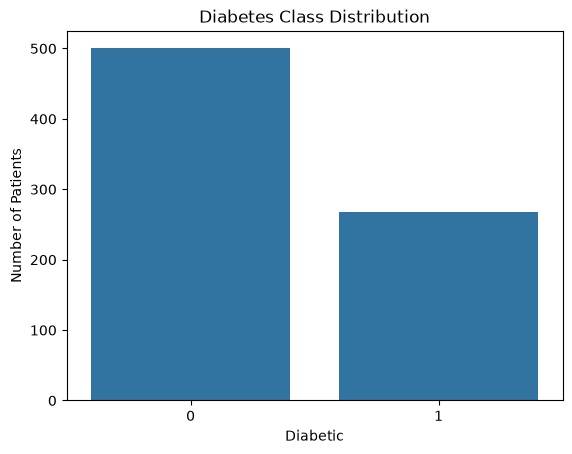

In [12]:
sns.countplot(data=df, x='Diabetic')
plt.title('Diabetes Class Distribution')
plt.xlabel('Diabetic')
plt.ylabel('Number of Patients')
plt.show()

In [19]:
zero_as_missing = [
    'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
    'Diastolic blood pressure (mm Hg)',
    'Triceps skinfold thickness',
    '2-Hour serum insulin',
    'BMI'
]

df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

In [23]:
zero_counts = (df == 0).sum()
zero_counts[zero_counts > 0]

Number of times pregnant    111
Diabetic                    500
dtype: int64

Treatment of Zero Values

During data preparation, I found zero values in a few variables where zero would not be biologically possible for a living patient. These variables were Plasma glucose concentration, Diastolic blood pressure, Triceps skinfold thickness, 2-Hour serum insulin, and BMI. As indicated in the assignment, these values were most likely missing or unrecorded measurements rather than actual zeros.

I treated these zeros as missing values by replacing them with `NaN`. The missing values were then filled using median imputation. I chose the median because it is less influenced by extreme values than the mean and provides a reasonable estimate for these medical measurements.

However, we did not treat all zeros in the dataset as missing. The `Diabetic` variable has 500 zero values, but these are valid observations because `0` indicates that the patient tested negative for diabetes. Similarly, a value of zero for `Number of times pregnant` is valid since a patient may have had no pregnancies.

After the imputation, there were no missing values left in the predictor variables. This gave us a complete dataset for building the classification models while retaining all 768 patient records.


In [24]:
# X contains the input variables used to predict diabetes
X = df.drop('Diabetic', axis=1)

# y contains the target variable
y = df['Diabetic']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (768, 8)
Shape of y: (768,)


In [27]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training data and 20% test data
# random_state=42 makes the split reproducible
# stratify=y keeps the proportion of diabetic and non-diabetic cases similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
# Check the number of observations in each dataset
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Check the target distribution in the training set
print("\nTraining target distribution:")
print(y_train.value_counts())

# Check the target distribution in the test set
print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (614, 8)
Test set: (154, 8)

Training target distribution:
Diabetic
0    400
1    214
Name: count, dtype: int64

Test target distribution:
Diabetic
0    100
1     54
Name: count, dtype: int64


In [ ]:
Task B — Build a Decision Tree Model

In [68]:
#Tree without pruning
from sklearn import tree
dt_model = tree.DecisionTreeClassifier(criterion = 'gini',random_state=1,min_samples_split=2,
    min_samples_leaf=1)
dt_model.fit(X_train, y_train)
print("Decision Tree Training Accuracy: ",dt_model.score(X_train,y_train))
print("Decision Tree Testing Accuracy: ",dt_model.score(X_test,y_test))

Decision Tree Training Accuracy:  1.0
Decision Tree Testing Accuracy:  0.6753246753246753


In [29]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model with pruning
# max_depth=5 limits the depth of the tree and helps control overfitting
# random_state=42 makes the result reproducible
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model using the training data
dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

I selected max_depth = 5 to control overfitting. 
A Decision Tree that grows too deep can learn the training data too closely and perform poorly on new data. 
A depth of 5 provides enough flexibility to capture useful patterns while keeping the model reasonably simple.

In [30]:
# Predict diabetes outcomes for the test data
y_pred_dt = dt_model.predict(X_test)

In [55]:
print("Decision Tree Training Accuracy: ",dt_model.score(X_train,y_train))
print("Decision Tree Testing Accuracy: ",dt_model.score(X_test,y_test))

Decision Tree Training Accuracy:  0.8127035830618893
Decision Tree Testing Accuracy:  0.7792207792207793


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate the required evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.7792
Precision: 0.6667
Recall   : 0.7407
F1 Score : 0.7018


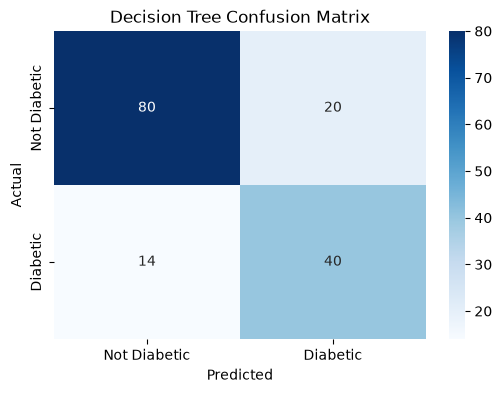

In [48]:
# Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Diabetic', 'Diabetic'],
    yticklabels=['Not Diabetic', 'Diabetic']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()

Task C — Build a Random Forest Model

In [49]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
# n_estimators=100 creates 100 trees and gives a more stable prediction
# max_depth=5 limits tree depth and helps reduce overfitting
# random_state=42 makes the result reproducible
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train the model using the same training data used for the Decision Tree
rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [50]:
# Predict diabetes outcomes for the test data
y_pred_rf = rf_model.predict(X_test)

In [56]:
print("Random Forest Training Accuracy: ",rf_model.score(X_train,y_train))
print("Random Forest Testing Accuracy: ",rf_model.score(X_test,y_test))

Random Forest Training Accuracy:  0.8599348534201955
Random Forest Testing Accuracy:  0.7272727272727273


In [52]:
# Calculate the required evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest Performance
-------------------------
Accuracy : 0.7273
Precision: 0.6364
Recall   : 0.5185
F1 Score : 0.5714


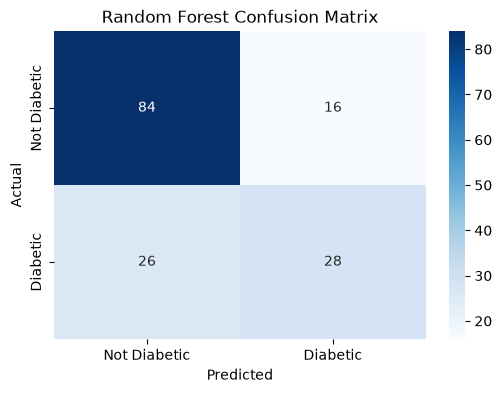

In [53]:
# Display the Random Forest confusion matrix
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Diabetic', 'Diabetic'],
    yticklabels=['Not Diabetic', 'Diabetic']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

Task D — Compare the Two Models

In [57]:
# Compare the two models using the required test-set metrics

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Decision Tree': [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt
    ],
    'Random Forest': [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf
    ]
})

comparison.round(4)

,Metric,Decision Tree,Random Forest
0,Accuracy,0.7792,0.7273
1,Precision,0.6667,0.6364
2,Recall,0.7407,0.5185
3,F1 Score,0.7018,0.5714


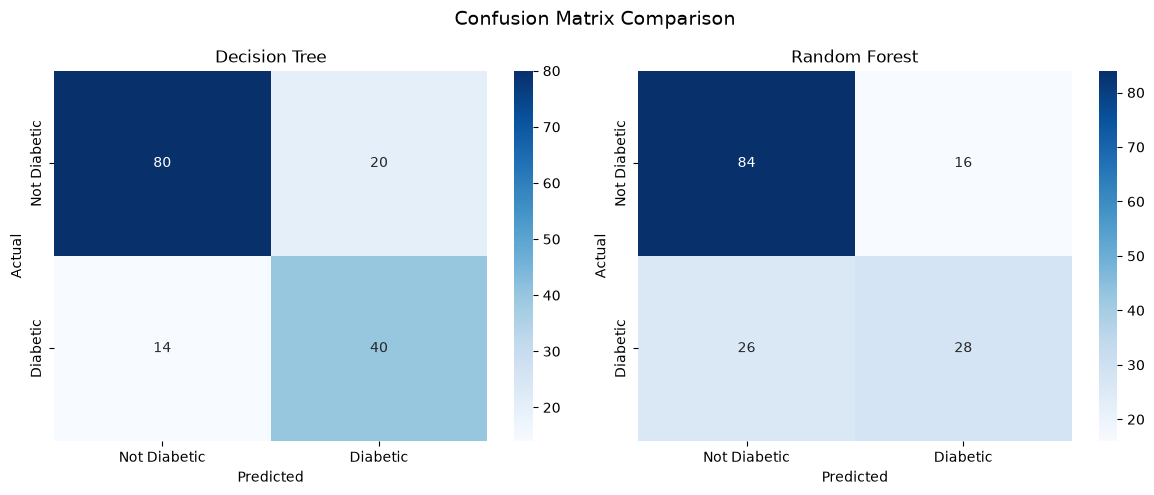

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree confusion matrix
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Diabetic', 'Diabetic'],
    yticklabels=['Not Diabetic', 'Diabetic'],
    ax=axes[0]
)
axes[0].set_title('Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Diabetic', 'Diabetic'],
    yticklabels=['Not Diabetic', 'Diabetic'],
    ax=axes[1]
)
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [63]:
# Extract the importance of each feature from the Decision Tree
# Higher importance means the feature contributed more to the tree's predictions

dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
})

# Sort features from most important to least important
dt_importance = dt_importance.sort_values(
    by='Importance',
    ascending=False
)
print("Decision Tree")
dt_importance

Decision Tree


,Feature,Importance
1,Plasma glucose concentration a 2 hours in an o...,0.572605
5,BMI,0.200785
7,Age,0.111908
4,2-Hour serum insulin,0.036989
6,Diabetes pedigree function,0.033907
2,Diastolic blood pressure (mm Hg),0.031427
3,Triceps skinfold thickness,0.012380
0,Number of times pregnant,0.000000


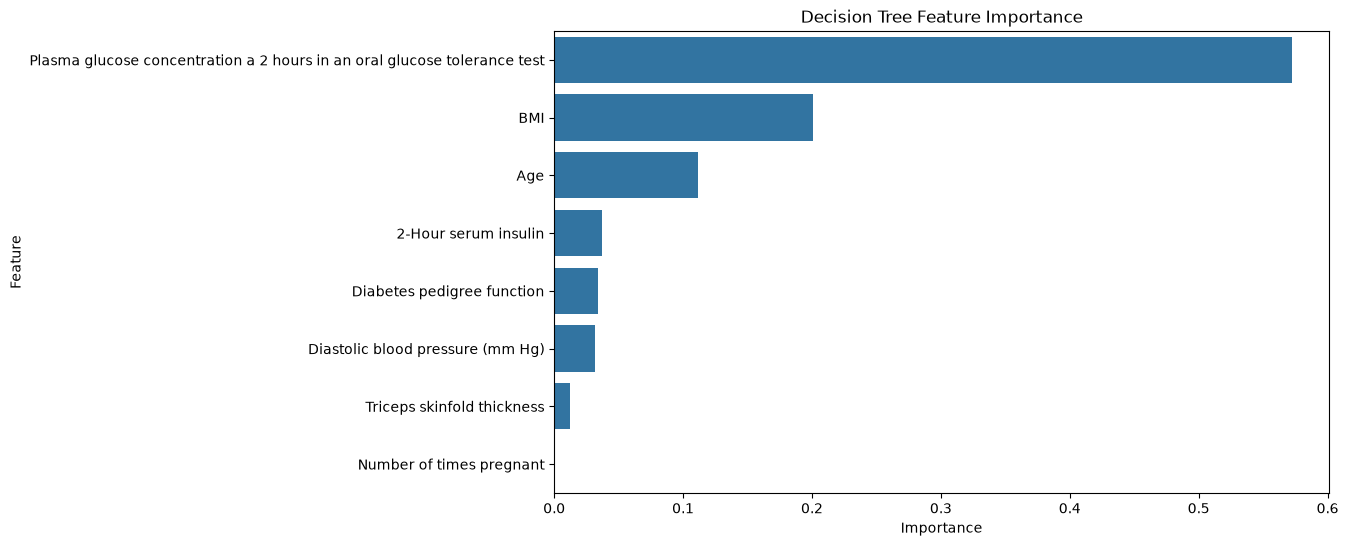

In [60]:
# Plot Decision Tree feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dt_importance,
    x='Importance',
    y='Feature'
)

plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [64]:
# Extract feature importance from the Random Forest
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features from most important to least important
rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)
print("Random Forest")
rf_importance

Random Forest


,Feature,Importance
1,Plasma glucose concentration a 2 hours in an o...,0.375268
5,BMI,0.164133
7,Age,0.110846
4,2-Hour serum insulin,0.100080
6,Diabetes pedigree function,0.079735
3,Triceps skinfold thickness,0.059688
0,Number of times pregnant,0.055314
2,Diastolic blood pressure (mm Hg),0.054936


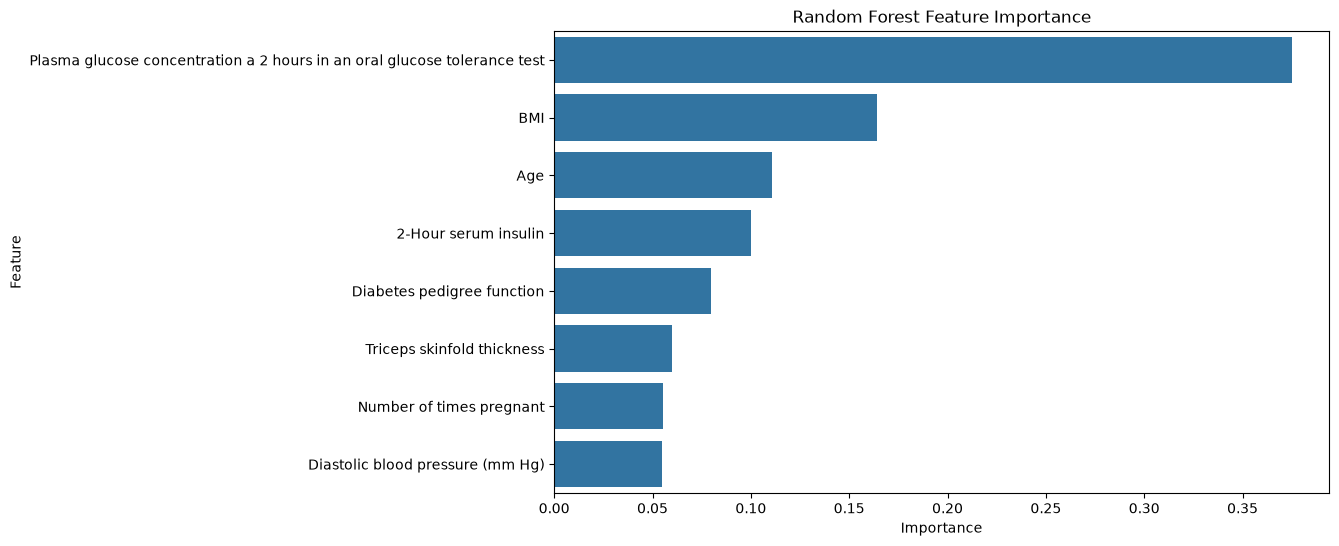

In [62]:
# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

TASK - E 

Decision Tree(DT) model was superior to Random Forest(RF) model on every metric. Accuracy was 77.92% versus 72.73%, Precision was 66.67% against 63.64%. DT model scored high on Recall with score of 74.07% versus just 51.85% for the Random Forest. F1 followed the same pattern with DT haing a score of 70.18% compared to 57.14%. Decision Tree is the clear winner.

The confusion matrices data above also shows Decision Tree as clear winner. The Decision Tree caught 40 diabetic patients and missed 14. The Random Forest only caught 28 and missed 26. This is important because a missed diagnosis means a patient doesn't get referred for further care. This also shows that Decision Tree is the stronger choice for this task.

Feature importance: Plasma glucose concentration mattered most for both models, 57.26% in the Decision Tree and 37.53% in the Random Forest. BMI and age followed in both. So glucose, weight and age are clearly driving these predictions. The Random Forest spread its weight and gives more credit to insulin, diabetes pedigree function, triceps skinfold thickness and pregnancy count. But importance isn't causation. High importance just means the model leans on that variable and not that it causes diabetes.

Considering all this, I believe the Decision Tree is better for the screening use case. Better accuracy, better recall, fewer false negatives, and a smaller gap between training and testing performance. Decision Tree had a training accuracy of 81.27% and testing accuracy of 77.92%. But  the Random Forest had training accuracy of 85.99% but it dropped to 72.73% on test data. That's a bigger gap and it points to overfitting

Limitation: The dataset isn't huge, and some values were missing or recorded as zero, which we handled through median imputation. A bigger, cleaner dataset would strengthen these conclusions. Going forward, testing different hyperparameters and running cross validation would help confirm whether the Decision Tree holds up across different samples, not just this one split.